In [1]:
import numpy as np # Linear Algebra
import scipy # For matrix exponential
import matplotlib.pyplot as plt # Plotting

In [2]:
#Continuous-time dynamics model
g = 9.8
Ac = np.array([[0., 1.], [0., 0.]])
cc = np.array([[0], [-g]])

In [32]:
#Create discrete-time dynamics model
dt = 0.1
D = np.block([[Ac,cc], [0,0,0]])
M = scipy.linalg.expm(dt*D)
A = np.array([[1., dt], [0., 1]])
c = M[0:2,2]

In [44]:
#Noise covariances
V = 0.01 #process noise
W = 1.0 #measurment noise

In [45]:
#Initial conditions
x0 = np.random.multivariate_normal(np.zeros((2,)), np.eye(2))

In [55]:
#Simulate with process noise
Tfinal = 2.0
Nt = 21
xtraj = np.zeros((2, Nt))
xtraj[:,0] = x0
for k in range(Nt-1):
    xtraj[:,k+1] = A @ xtraj[:,k] + c + V

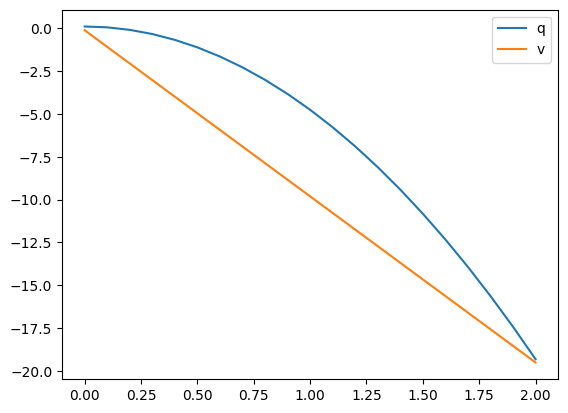

In [56]:
times = np.linspace(0,Tfinal,Nt)
plt.plot(times, xtraj[0,:], label='q')
plt.plot(times, xtraj[1,:], label='v')
plt.legend()

In [60]:
# Generate noisy measurements
ytraj = c @ xtraj+ W

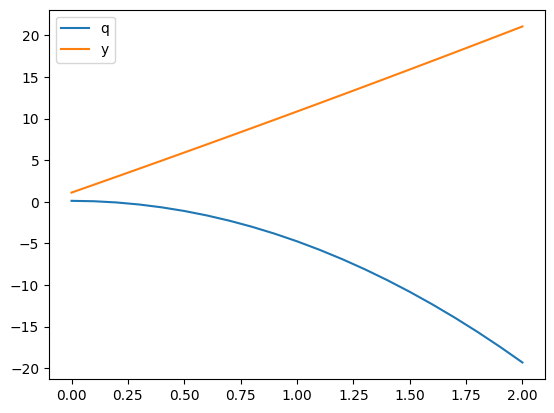

In [61]:
plt.plot(times, xtraj[0,:], label='q')
plt.plot(times, ytraj, label='y')
plt.legend()

In [ ]:
# Define the measurement model
C = ##Fill me in

In [ ]:
#Filter Initialization
xfilt = np.zeros((2,Nt))
xfilt[:,0] = np.random.multivariate_normal(xtraj[:,0], np.eye(2))

P = np.zeros((2,2,Nt))
P[:,:,0] = np.eye(2)

In [62]:
for k in range(Nt-1):
    #Prediction
    xpred = A @ xtraj[:,k] + C
    Ppred = A @ P @ np.transpose(A) + V

    #Innovation
    z = ##Fill me in
    S = ##Fill me in

    #Kalman Gain
    L = ##Fill me in

    #Update
    xfilt[:,k+1] = ##Fill me in
    P[:,:,k+1] = ##Fill me in

SyntaxError: invalid syntax (3121879885.py, line 7)

In [ ]:
# Plot the estimate vs. the ground truth
plt.plot(times, xtraj[0,:], label='qtrue')
plt.plot(times, xfilt[0,:], label='qfilt')
plt.plot(times, ytraj, label='y')
plt.legend()

In [ ]:
plt.plot(times, xtraj[1,:], label='vtrue')
plt.plot(times, xfilt[1,:], label='vfilt')
plt.legend()

In [ ]:
#Plot covariance components
plt.plot(times, P[0,0,:], label='P11')
plt.plot(times, P[1,1,:], label='P22')
plt.legend()